In [1]:
import pandas as pd
import numpy as np
import joblib
import time

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

test_df = dataset["test"].to_pandas()

print(test_df.shape)

(25000, 2)


In [3]:
tfidf = joblib.load(
    "models/tfidf_vectorizer.pkl"
)

lr_model = joblib.load(
    "models/logistic_regression.pkl"
)

In [4]:
X_test = tfidf.transform(
    test_df["text"]
)

y_test = test_df["label"]

In [5]:
start_time = time.time()

y_test_pred_lr = lr_model.predict(X_test)
y_test_prob_lr = lr_model.predict_proba(X_test)[:, 1]

end_time = time.time()

baseline_test_latency = (
    end_time - start_time
) / len(test_df)

In [6]:
baseline_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_lr
)

baseline_test_precision = precision_score(
    y_test,
    y_test_pred_lr
)

baseline_test_recall = recall_score(
    y_test,
    y_test_pred_lr
)

baseline_test_f1 = f1_score(
    y_test,
    y_test_pred_lr
)

baseline_test_roc_auc = roc_auc_score(
    y_test,
    y_test_prob_lr
)

In [7]:
print("TF-IDF + Logistic Regression — TEST SET")
print("---------------------------------------")
print(f"Accuracy : {baseline_test_accuracy:.4f}")
print(f"Precision: {baseline_test_precision:.4f}")
print(f"Recall   : {baseline_test_recall:.4f}")
print(f"F1 Score : {baseline_test_f1:.4f}")
print(f"ROC-AUC  : {baseline_test_roc_auc:.4f}")
print(f"Latency : {baseline_test_latency:.6f} sec/review")

TF-IDF + Logistic Regression — TEST SET
---------------------------------------
Accuracy : 0.8911
Precision: 0.8873
Recall   : 0.8959
F1 Score : 0.8916
ROC-AUC  : 0.9580
Latency : 0.000001 sec/review


In [8]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

tokenizer = AutoTokenizer.from_pretrained(
    "models/distilbert_development"
)

model = AutoModelForSequenceClassification.from_pretrained(
    "models/distilbert_development"
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [9]:
from datasets import Dataset

test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]],
    preserve_index=False
)

In [10]:
MAX_LENGTH = 256

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [15]:
from transformers import TrainingArguments, Trainer

evaluation_args = TrainingArguments(
    output_dir="./models/evaluation",
    per_device_eval_batch_size=8,
    report_to="none"
)

eval_trainer = Trainer(
    model=model,
    args=evaluation_args,
    processing_class=tokenizer
)

In [13]:
start_time = time.time()

distilbert_test_predictions = eval_trainer.predict(
    tokenized_test
)

end_time = time.time()

C:\Users\PAVITHRA\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [16]:
y_test_pred_distilbert = np.argmax(
    distilbert_test_predictions.predictions,
    axis=1
)

In [17]:
from scipy.special import softmax

test_probabilities = softmax(
    distilbert_test_predictions.predictions,
    axis=1
)

y_test_prob_distilbert = test_probabilities[:, 1]

In [18]:
distilbert_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_distilbert
)

distilbert_test_precision = precision_score(
    y_test,
    y_test_pred_distilbert
)

distilbert_test_recall = recall_score(
    y_test,
    y_test_pred_distilbert
)

distilbert_test_f1 = f1_score(
    y_test,
    y_test_pred_distilbert
)

distilbert_test_roc_auc = roc_auc_score(
    y_test,
    y_test_prob_distilbert
)

distilbert_test_latency = (
    end_time - start_time
) / len(test_df)

In [19]:
print("DistilBERT — TEST SET")
print("---------------------")
print(f"Accuracy : {distilbert_test_accuracy:.4f}")
print(f"Precision: {distilbert_test_precision:.4f}")
print(f"Recall   : {distilbert_test_recall:.4f}")
print(f"F1 Score : {distilbert_test_f1:.4f}")
print(f"ROC-AUC  : {distilbert_test_roc_auc:.4f}")
print(f"Latency : {distilbert_test_latency:.6f} sec/review")

DistilBERT — TEST SET
---------------------
Accuracy : 0.8791
Precision: 0.8570
Recall   : 0.9101
F1 Score : 0.8828
ROC-AUC  : 0.9535
Latency : 0.224930 sec/review


In [20]:
final_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Inference Latency (sec/review)"
    ],

    "TF-IDF + Logistic Regression": [
        baseline_test_accuracy,
        baseline_test_precision,
        baseline_test_recall,
        baseline_test_f1,
        baseline_test_roc_auc,
        baseline_test_latency
    ],

    "DistilBERT": [
        distilbert_test_accuracy,
        distilbert_test_precision,
        distilbert_test_recall,
        distilbert_test_f1,
        distilbert_test_roc_auc,
        distilbert_test_latency
    ]
})

final_comparison

,Metric,TF-IDF + Logistic Regression,DistilBERT
0,Accuracy,0.891080,0.879120
1,Precision,0.887331,0.857014
2,Recall,0.895920,0.910080
3,F1 Score,0.891605,0.882750
4,ROC-AUC,0.958025,0.953485
5,Inference Latency (sec/review),0.000001,0.224930


In [21]:
final_comparison.to_csv(
    "models/final_model_comparison.csv",
    index=False
)

In [22]:
cm_lr_test = confusion_matrix(
    y_test,
    y_test_pred_lr
)

print(cm_lr_test)

[[11078  1422]
 [ 1301 11199]]


In [23]:
cm_distilbert_test = confusion_matrix(
    y_test,
    y_test_pred_distilbert
)

print(cm_distilbert_test)

[[10602  1898]
 [ 1124 11376]]


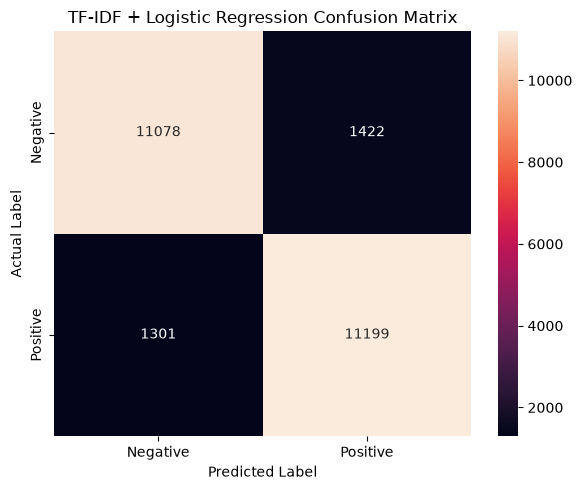

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("plots", exist_ok=True)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr_test,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("TF-IDF + Logistic Regression Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "plots/confusion_matrix_lr_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

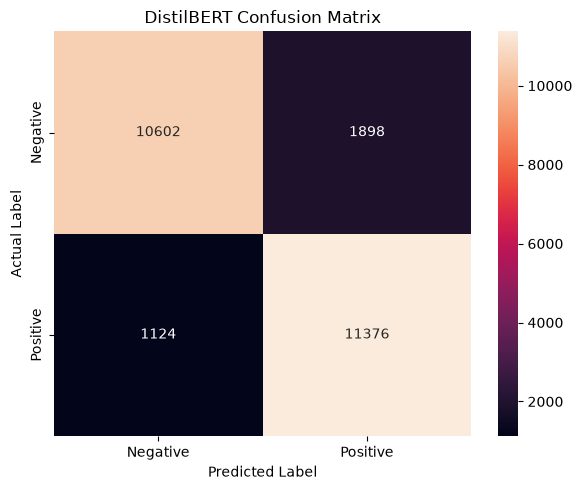

In [25]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_distilbert_test,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("DistilBERT Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "plots/confusion_matrix_distilbert_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
lr_errors = pd.DataFrame({
    "text": test_df["text"],
    "actual": y_test,
    "predicted": y_test_pred_lr
})

lr_errors = lr_errors[
    lr_errors["actual"] != lr_errors["predicted"]
]

In [27]:
distilbert_errors = pd.DataFrame({
    "text": test_df["text"],
    "actual": y_test,
    "predicted": y_test_pred_distilbert
})

distilbert_errors = distilbert_errors[
    distilbert_errors["actual"] != distilbert_errors["predicted"]
]

In [28]:
lr_errors.head(10)

,text,actual,predicted
4,"First off let me say, If you haven't enjoyed a...",0,1
18,"Ben, (Rupert Grint), is a deeply unhappy adole...",0,1
22,The Forgotten (AKA: Don't Look In The Basement...,0,1
28,Four things intrigued me as to this film - fir...,0,1
32,I'm the type of guy who loves hood movies from...,0,1
46,"Okay, so it was never going to change the worl...",0,1
61,This film features two of my favorite guilty p...,0,1
63,This only gets bashed because it stars David H...,0,1
79,"It's Saturday, it's raining, and I think every...",0,1
92,"Maniratnam, who in India, is often compared wi...",0,1


In [29]:
distilbert_errors.head(10)

,text,actual,predicted
4,"First off let me say, If you haven't enjoyed a...",0,1
6,Isaac Florentine has made some of the best wes...,0,1
11,"Blind Date (Columbia Pictures, 1934), was a de...",0,1
18,"Ben, (Rupert Grint), is a deeply unhappy adole...",0,1
20,Low budget horror movie. If you don't raise yo...,0,1
32,I'm the type of guy who loves hood movies from...,0,1
37,The only reason this movie is not given a 1 (a...,0,1
46,"Okay, so it was never going to change the worl...",0,1
56,There are many different versions of this one ...,0,1
61,This film features two of my favorite guilty p...,0,1


In [30]:
final_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Inference Latency (sec/review)"
    ],
    "TF-IDF + Logistic Regression": [
        baseline_test_accuracy,
        baseline_test_precision,
        baseline_test_recall,
        baseline_test_f1,
        baseline_test_roc_auc,
        baseline_test_latency
    ],
    "DistilBERT": [
        distilbert_test_accuracy,
        distilbert_test_precision,
        distilbert_test_recall,
        distilbert_test_f1,
        distilbert_test_roc_auc,
        distilbert_test_latency
    ]
})

final_comparison

,Metric,TF-IDF + Logistic Regression,DistilBERT
0,Accuracy,0.891080,0.879120
1,Precision,0.887331,0.857014
2,Recall,0.895920,0.910080
3,F1 Score,0.891605,0.882750
4,ROC-AUC,0.958025,0.953485
5,Inference Latency (sec/review),0.000001,0.224930


In [31]:
final_comparison.to_csv(
    "models/final_model_comparison.csv",
    index=False
)

In [32]:
lr_errors = pd.DataFrame({
    "text": test_df["text"],
    "actual": y_test,
    "predicted": y_test_pred_lr
})

lr_errors = lr_errors[
    lr_errors["actual"] != lr_errors["predicted"]
]

In [33]:
distilbert_errors = pd.DataFrame({
    "text": test_df["text"],
    "actual": y_test,
    "predicted": y_test_pred_distilbert
})

distilbert_errors = distilbert_errors[
    distilbert_errors["actual"] !=
    distilbert_errors["predicted"]
]

In [34]:
lr_errors.to_csv(
    "models/logistic_regression_errors.csv",
    index=False
)

distilbert_errors.to_csv(
    "models/distilbert_errors.csv",
    index=False
)

In [35]:
lr_errors.head(10)

,text,actual,predicted
4,"First off let me say, If you haven't enjoyed a...",0,1
18,"Ben, (Rupert Grint), is a deeply unhappy adole...",0,1
22,The Forgotten (AKA: Don't Look In The Basement...,0,1
28,Four things intrigued me as to this film - fir...,0,1
32,I'm the type of guy who loves hood movies from...,0,1
46,"Okay, so it was never going to change the worl...",0,1
61,This film features two of my favorite guilty p...,0,1
63,This only gets bashed because it stars David H...,0,1
79,"It's Saturday, it's raining, and I think every...",0,1
92,"Maniratnam, who in India, is often compared wi...",0,1


In [36]:
distilbert_errors.head(10)

,text,actual,predicted
4,"First off let me say, If you haven't enjoyed a...",0,1
6,Isaac Florentine has made some of the best wes...,0,1
11,"Blind Date (Columbia Pictures, 1934), was a de...",0,1
18,"Ben, (Rupert Grint), is a deeply unhappy adole...",0,1
20,Low budget horror movie. If you don't raise yo...,0,1
32,I'm the type of guy who loves hood movies from...,0,1
37,The only reason this movie is not given a 1 (a...,0,1
46,"Okay, so it was never going to change the worl...",0,1
56,There are many different versions of this one ...,0,1
61,This film features two of my favorite guilty p...,0,1


The TF-IDF + Logistic Regression baseline achieved the best overall test-set performance and substantially lower inference latency, while DistilBERT achieved higher recall. Therefore, TF-IDF + Logistic Regression is selected as the final deployment model for this project, while DistilBERT serves as the advanced-model benchmark.

In [37]:
cm_lr_test = confusion_matrix(
    y_test,
    y_test_pred_lr
)

print("TF-IDF + Logistic Regression")
print(cm_lr_test)

TF-IDF + Logistic Regression
[[11078  1422]
 [ 1301 11199]]


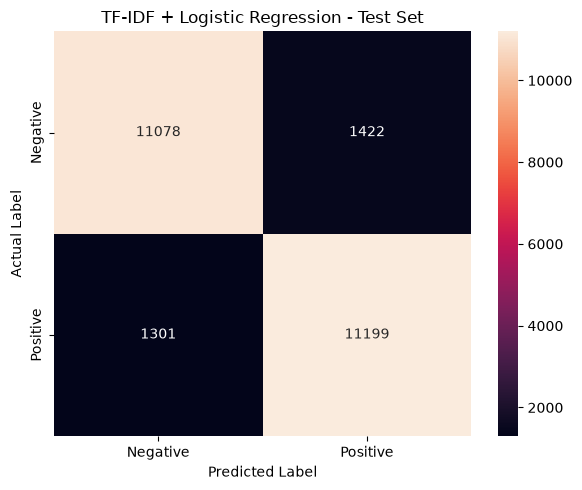

In [40]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr_test,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("TF-IDF + Logistic Regression - Test Set")

plt.tight_layout()

plt.savefig(
    "plots/confusion_matrix_lr_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
cm_distilbert_test = confusion_matrix(
    y_test,
    y_test_pred_distilbert
)

print("DistilBERT")
print(cm_distilbert_test)

DistilBERT
[[10602  1898]
 [ 1124 11376]]


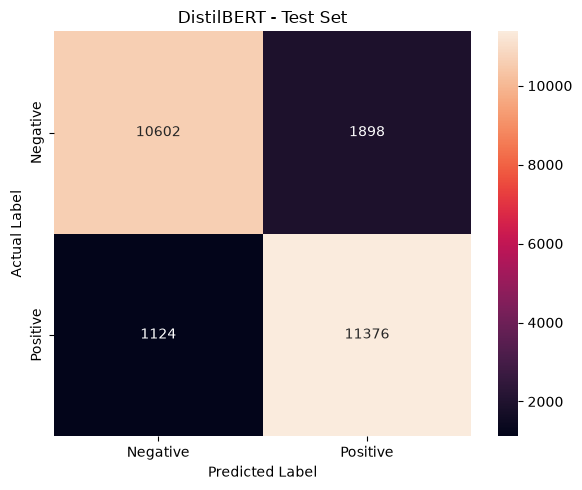

In [41]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_distilbert_test,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("DistilBERT - Test Set")

plt.tight_layout()

plt.savefig(
    "plots/confusion_matrix_distilbert_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
lr_errors = pd.DataFrame({
    "text": test_df["text"],
    "actual": y_test,
    "predicted": y_test_pred_lr
})

lr_errors = lr_errors[
    lr_errors["actual"] != lr_errors["predicted"]
].copy()

In [43]:
distilbert_errors = pd.DataFrame({
    "text": test_df["text"],
    "actual": y_test,
    "predicted": y_test_pred_distilbert
})

distilbert_errors = distilbert_errors[
    distilbert_errors["actual"] !=
    distilbert_errors["predicted"]
].copy()

In [44]:
print("Logistic Regression errors:", len(lr_errors))
print("DistilBERT errors:", len(distilbert_errors))

Logistic Regression errors: 2723
DistilBERT errors: 3022


In [48]:
lr_errors.head(10)

,text,actual,predicted
4,"First off let me say, If you haven't enjoyed a...",0,1
18,"Ben, (Rupert Grint), is a deeply unhappy adole...",0,1
22,The Forgotten (AKA: Don't Look In The Basement...,0,1
28,Four things intrigued me as to this film - fir...,0,1
32,I'm the type of guy who loves hood movies from...,0,1
46,"Okay, so it was never going to change the worl...",0,1
61,This film features two of my favorite guilty p...,0,1
63,This only gets bashed because it stars David H...,0,1
79,"It's Saturday, it's raining, and I think every...",0,1
92,"Maniratnam, who in India, is often compared wi...",0,1


In [49]:
lr_errors[
    lr_errors["text"].str.contains(
        "The acting was excellent",
        case=False,
        na=False
    )
][["text", "actual", "predicted"]]

,text,actual,predicted


In [50]:
distilbert_errors.head(10)

,text,actual,predicted
4,"First off let me say, If you haven't enjoyed a...",0,1
6,Isaac Florentine has made some of the best wes...,0,1
11,"Blind Date (Columbia Pictures, 1934), was a de...",0,1
18,"Ben, (Rupert Grint), is a deeply unhappy adole...",0,1
20,Low budget horror movie. If you don't raise yo...,0,1
32,I'm the type of guy who loves hood movies from...,0,1
37,The only reason this movie is not given a 1 (a...,0,1
46,"Okay, so it was never going to change the worl...",0,1
56,There are many different versions of this one ...,0,1
61,This film features two of my favorite guilty p...,0,1


TF-IDF + Logistic Regression achieved the strongest overall test-set performance, with 89.11% accuracy, 88.73% precision, 89.59% recall, 89.16% F1-score, and 95.80% ROC-AUC. DistilBERT achieved 87.91% accuracy, 85.70% precision, 91.01% recall, 88.28% F1-score, and 95.35% ROC-AUC. Although DistilBERT achieved higher recall, TF-IDF + Logistic Regression provided better overall predictive performance and substantially lower inference latency. Therefore, TF-IDF + Logistic Regression was selected as the final deployment model, while DistilBERT was retained as the advanced-model benchmark.